# 01 · Ascenso por máxima pendiente (Python)

**Semana 4 — Optimización (RSM).**

## Objetivos
- Ajustar un **modelo de primer orden** con puntos centrales.
- Calcular la **trayectoria de máxima pendiente** hacia la región óptima.

> Teoría: [`../teoria/01-rsm-ascenso.md`](../teoria/01-rsm-ascenso.md).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

np.random.seed(9)

## 1. Los datos

Región **alejada** del óptimo: un $2^2$ con 3 puntos centrales en variables codificadas. La superficie es aún casi **plana** (primer orden).

In [2]:
df = pd.read_csv('../datos/proceso-primer-orden.csv')
df

,x1,x2,y
0,-1,-1,33.00
1,1,-1,42.88
2,-1,1,36.55
3,1,1,46.99
4,0,0,39.85
5,0,0,39.81
6,0,0,39.39


## 2. Modelo de primer orden

$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2$.

In [3]:
modelo = smf.ols('y ~ x1 + x2', data=df).fit()
print(modelo.params.round(3))
print(f'R2 = {modelo.rsquared:.4f}')

Intercept    39.781
x1            5.080
x2            1.915
dtype: float64
R2 = 0.9978


El alto $R^2$ confirma que el modelo lineal describe bien esta región (lejos de la curvatura). El **gradiente** $(\beta_1,\beta_2)$ marca la dirección de ascenso.

## 3. Trayectoria de máxima pendiente

Tomamos $x_1$ como referencia con paso $\Delta x_1=1$; el paso de $x_2$ es proporcional: $\Delta x_2 = (\beta_2/\beta_1)\,\Delta x_1$.

In [4]:
b1, b2 = modelo.params['x1'], modelo.params['x2']
paso_x1 = 1.0
paso_x2 = (b2 / b1) * paso_x1
pasos = np.arange(0, 6)
ruta = pd.DataFrame({'paso': pasos,
                     'x1': pasos * paso_x1,
                     'x2': (pasos * paso_x2).round(3)})
ruta['y_pred'] = modelo.predict(ruta[['x1','x2']])
ruta

,paso,x1,x2,y_pred
0,0,0.0,0.000,39.781429
1,1,1.0,0.377,45.583384
2,2,2.0,0.754,51.385339
3,3,3.0,1.131,57.187294
4,4,4.0,1.508,62.989249
5,5,5.0,1.885,68.791204


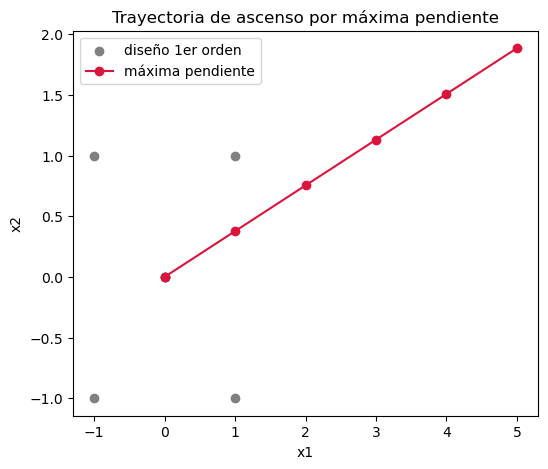

In [5]:
fig, ax = plt.subplots(figsize=(6,5))
ax.scatter(df.x1, df.x2, c='gray', label='diseño 1er orden')
ax.plot(ruta.x1, ruta.x2, 'o-', color='crimson', label='máxima pendiente')
ax.set_xlabel('x1'); ax.set_ylabel('x2'); ax.legend()
ax.set_title('Trayectoria de ascenso por máxima pendiente'); plt.show()

## 4. Interpretación

Se realizarían corridas **reales** a lo largo de esta trayectoria (pasos 1, 2, 3…) midiendo la respuesta, y se avanzaría **mientras mejore**. Cuando la respuesta deje de aumentar, se ajusta un nuevo modelo de primer orden en esa vecindad o se pasa al **modelo de segundo orden** (notebook 02).

> Equivalente en R: [`01-ascenso-pendiente_r.ipynb`](01-ascenso-pendiente_r.ipynb).